# Wstęp
Projekt powstał w oparciu o bazę danych RAVDESS Emotional Speech Audio, zawierającą nagrania wypowiedzi o różnym zabarwieniu emocjonalnym. Zbiór ten składa się z próbek mowy aktorów, w których każda wypowiedź została jednoznacznie oznaczona jedną z ośmiu klas emocji:
*(01 – neutralna, 02 – spokojna, 03 – szczęśliwa, 04 – smutna, 05 – zła, 06 – przestraszona, 07 – wstręt, 08 – zaskoczona)*.

Cała baza danych jest stosunkowo niewielka, zawiera 1440 plików audio.

Celem projektu było zaprojektowanie oraz analiza kompletnego pipeline’u klasyfikacji emocji w mowie, obejmującego ekstrakcję cech, ich przetwarzanie oraz klasyfikację przy użyciu wybranych algorytmów uczenia maszynowego. W szczególności skupiono się na porównaniu skuteczności modeli Support Vector Machine (SVM) oraz Random Forest zarówno w zadaniu klasyfikacji wieloklasowej, jak i binarnej.

W ramach pracy wykorzystano reprezentacje sygnału mowy, takie jak współczynniki MFCC wraz z pochodnymi (delta i delta-delta) oraz spektrogram, które następnie zostały opisane za pomocą zestawu statystyk. Dodatkowo przeprowadzono proces optymalizacji parametrów modeli z użyciem walidacji krzyżowej oraz narzędzia Optuna.

In [ ]:
!pip install optuna
import os
import numpy as np
import pandas as pd
import librosa
import kagglehub
import optuna
import random
from scipy.io.wavfile import read as read_wav
from scipy.signal import ShortTimeFFT
from scipy.stats import kurtosis, skew
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay as CMD
from sklearn.metrics import accuracy_score, f1_score, make_scorer, roc_auc_score, roc_curve, recall_score, precision_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate,cross_val_score, StratifiedKFold
from matplotlib import pyplot as plt
from IPython.display import Audio
from collections import Counter
from optuna.samplers import TPESampler
from optuna import create_study

Wczytanie bazy danych oraz jej wstępne rozdzielenie.

In [ ]:
ravdess = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

ravdess_directory_list = os.listdir(ravdess)
file_path = []
emotions_numbers = []  #etykiety
actors_numbers = []


ravdess_directory_list = os.listdir(ravdess)

for actor in ravdess_directory_list:
    actor_path = os.path.join(ravdess, actor)
    for file in os.listdir(actor_path):
        if not file.endswith('.wav'):
            continue
        file_path.append(os.path.join(actor_path, file))
        emotions_numbers.append(int(file.split('-')[2]))
        actors_numbers.append(file.split('-')[6])

print(len(file_path), "plików audio")
print("Przykładowa ścieżka:", file_path[0])

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
1440 plików audio
Przykładowa ścieżka: /kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav


Sprawdzenie czy dane są równoliczne - danych o etykiecie 1 jest mniej!

In [ ]:
emotion_counts = Counter(emotions_numbers)
print(emotion_counts)

Counter({8: 192, 7: 192, 6: 192, 4: 192, 2: 192, 3: 192, 5: 192, 1: 96})


Tworzymy data frame zawierający w odpowiednich kolumnach informacje o ścieżce do pliku, emocji jakie zawiera a także aktora który wypowiedział dane słowa.

In [ ]:
emotions_df = pd.DataFrame(emotions_numbers, columns=['Emotions']) #kolumna z emocjami
#print(emotions_df)
path_df = pd.DataFrame(file_path, columns=['Path']) #kolumna z ścieżką
#print(path_df)
actors_df = pd.DataFrame(actors_numbers, columns=['Actor']) #kolumna z aktorami
#print(actors_df)
emot_path_df = pd.concat([path_df, emotions_df, actors_df], axis=1) #złączenie w jeden data frame
emot_path_df['Emotions'] = emot_path_df['Emotions'].replace({1:'neutral', 2:'neutral', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}) #podmienienie etykiet emocji

emot_path_df = emot_path_df[emot_path_df['Emotions'].isin(['neutral', 'angry'])] #tu mozna wybrac do klasyfikacji binarnej
print(emot_path_df)

                                                   Path Emotions   Actor
1     /kaggle/input/ravdess-emotional-speech-audio/A...  neutral  02.wav
4     /kaggle/input/ravdess-emotional-speech-audio/A...  neutral  02.wav
7     /kaggle/input/ravdess-emotional-speech-audio/A...  neutral  02.wav
8     /kaggle/input/ravdess-emotional-speech-audio/A...  neutral  02.wav
11    /kaggle/input/ravdess-emotional-speech-audio/A...    angry  02.wav
...                                                 ...      ...     ...
1426  /kaggle/input/ravdess-emotional-speech-audio/A...    angry  07.wav
1427  /kaggle/input/ravdess-emotional-speech-audio/A...  neutral  07.wav
1433  /kaggle/input/ravdess-emotional-speech-audio/A...  neutral  07.wav
1436  /kaggle/input/ravdess-emotional-speech-audio/A...    angry  07.wav
1439  /kaggle/input/ravdess-emotional-speech-audio/A...    angry  07.wav

[480 rows x 3 columns]


Sprawdzenie czy są jakieś brakujące dane.

In [ ]:
print("Liczba brakujących danych w każdej kolumnie:")
print(emot_path_df.isnull().sum())

print("\nLiczba duplikatów całych wierszy:")
print(emot_path_df.duplicated().sum())

emot_path_df = emot_path_df.drop_duplicates()

print("\nUnikalne emocje w zbiorze danych:")
print(emot_path_df['Emotions'].unique())

#print(emot_path_df.head)

Liczba brakujących danych w każdej kolumnie:
Path        0
Emotions    0
Actor       0
dtype: int64

Liczba duplikatów całych wierszy:
0

Unikalne emocje w zbiorze danych:
['neutral' 'angry']


In [ ]:
# Sprawdzenie przykładowego pliku
example = emot_path_df[emot_path_df['Emotions'] == 'angry']['Path'].iloc[1]
data, sr = librosa.load(example, sr=None)
Audio(data, rate=sr)


Funkcja obliczająca zestaw statystyk (średnia, odchylenie standardowe, maksimum, minimum, mediana) dla danej reprezentacji sygnału audio.

In [ ]:
def compute_statistics(representation):
  mean_ = np.mean(representation, axis=1)   # średnia amplituda dla każdej częstotliwości
  std_ = np.std(representation, axis=1)     # odchylenie standardowe
  maximum_ = np.max(representation, axis=1)    # maksima
  minimum_ = np.min(representation, axis=1)  #minima
  median_ = np.median(representation, axis=1) #mediana
  #skew_ = skew(representation, axis=1) #skonosc
  #kurt_ = kurtosis(representation, axis=1) #kurtoza
  statistics = np.concatenate([mean_, std_, maximum_, minimum_, median_,
                               #skew_, kurt_
                               ])
  return statistics

Funkcja odpowiedzialna za wczytanie plików audio oraz obliczenie wybranych reprezentacji sygnału: MFCC oraz spektrogramu w skali dB. Dla każdej reprezentacji wyliczane jest zestaw statystyk, który ostatecznie tworzy wektor cech reprezentujący cały sygnał audio

<b>*Dodanie delt oraz delt-delt by zwiększyć dokładność modelu.*

In [ ]:
def feature_extractor(file_path, n_mfcc=20, #mfcc
                      n_fft=2048, win_length=None, window='hann'): #spectogram
  mfcc_features_list = []
  spectrogram_features_list = []
  for file in file_path:
    audio, sample_rate = librosa.load(file,sr=None)

    # MFCC
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc, n_fft=n_fft)
    #pierwsza zmiana, dodanie delt
    mfcc_delta = librosa.feature.delta(mfcc)# delta mfcc
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)# delta-delta mfcc
    mfcc_combined = np.concatenate([mfcc, mfcc_delta, mfcc_delta2], axis=0) # Łączymy wszystkie MFCC w jeden blok (podstawowe + delta + delta-delta)

    mfcc_stats = compute_statistics(mfcc_combined)
    mfcc_features_list.append(mfcc_stats)

    # Spektrogram w dB
    stft_ = librosa.stft(audio, n_fft=n_fft, win_length=win_length,window=window)
    spectrogram = librosa.amplitude_to_db(np.abs(stft_), ref=np.max)
    spectrogram_stats = compute_statistics(spectrogram)
    spectrogram_features_list.append(spectrogram_stats)

  # Zamiana list na macierze NumPy: (liczba_próbek × liczba_cech)
  mfcc_features_array = np.array(mfcc_features_list)
  spectrogram_features_array = np.array(spectrogram_features_list)

  return mfcc_features_array, spectrogram_features_array

Żeby sztucznie nie zawyrzać wyników musimy dokonać podziału na zbiór treningowy i testowy w taki sposób, by dani mówcy się nie pojawiali w obu zbiorach jednocześnie, mogłoby to prowadzić do sztucznego zawyżania wyników modelu.

Najpierw tworzymy odpowiednie indeksy.

In [ ]:
actors = emot_path_df['Actor'].unique()
rng = np.random.default_rng(seed=42)  #ustawaiamy jakis jeden konkretny seed zeby dobor za kazdy razem byl taki sam
test_actors = rng.choice(actors, size=int(0.2*len(actors)), replace=False)
train_actors = [a for a in actors if a not in test_actors]

Teraz filtrujemy i tworzymy odpowiednie zbiory na podstawie indeksów.

In [ ]:
train_df = emot_path_df[emot_path_df['Actor'].isin(train_actors)]
test_df = emot_path_df[emot_path_df['Actor'].isin(test_actors)]

train_paths = train_df['Path'].tolist() #konwersja na listy zeby mozna było podac te dane do funkcji feature extractor
test_paths = test_df['Path'].tolist()

Możemy teraz przejść do ekstrakcji cech na naszych zbiorach.

In [ ]:
mfcc_train, spec_train = feature_extractor(train_paths)
mfcc_test, spec_test = feature_extractor(test_paths)

Sprawdzamy wymiary naszych zbiorów cech (nagrania x cechy).

In [ ]:
print("Wymiary MFCC :", mfcc_train.shape)
print("Wymiary spektrogramu :", spec_train.shape)

Wymiary MFCC : (400, 300)
Wymiary spektrogramu : (400, 5125)


5125 cech dla spektogramów to dużo, po ustandaryzowaniu danych trzeba będzie przeprowadzić PCA.

Następnie przeprowadzamy osobno standaryzacje obu zbiorów.

In [ ]:
def perform_scaler(X_train, X_test):
    scaler = StandardScaler()
    train_std = scaler.fit_transform(X_train)
    test_std = scaler.transform(X_test)
    return train_std, test_std

In [ ]:
mfcc_train_std, mfcc_test_std = perform_scaler(mfcc_train, mfcc_test)
spec_train_std, spec_test_std = perform_scaler(spec_train, spec_test)

PCA

In [ ]:
def perform_pca(X_train, X_test, n_components):
    pca = PCA(n_components=n_components)
    train_pca = pca.fit_transform(X_train)
    test_pca = pca.transform(X_test)
    print("Wymiary spektrogramu po PCA:", train_pca.shape)
    return train_pca, test_pca

In [ ]:
spec_train_pca, spec_test_pca = perform_pca(spec_train_std, spec_test_std, 100)

Wymiary spektrogramu po PCA: (400, 100)


Teraz możemy ostatecznie połączyć zbiory odpowiednio na treningowy oraz testowy, składający sie z mfcc i spektogramów, a także utworzyć wektor etykiet.

In [ ]:
X_train = np.concatenate([mfcc_train_std, spec_train_pca], axis=1)
X_test  = np.concatenate([mfcc_test_std,  spec_test_pca], axis=1)
y_train = train_df['Emotions'].values
y_test  = test_df['Emotions'].values

In [ ]:
SVM = SVC(C=1, kernel='rbf', gamma='scale', random_state=42) #svm na domyslnych parametrach (przed optymalizacja)
SVM.fit(X_train, y_train)

SVC(C=1, random_state=42)

test accuracy =  0.925
test F1 =  0.9245556287030942


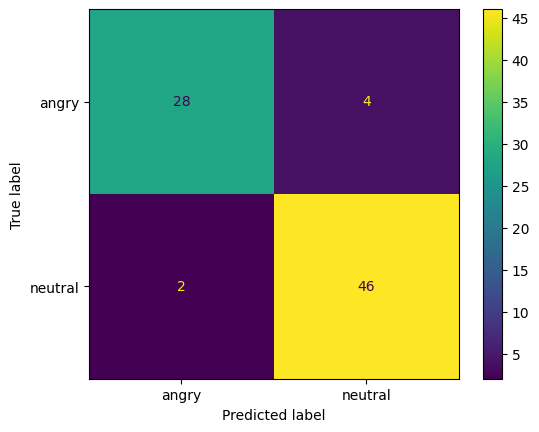

In [ ]:
SVM_test_preds = SVM.predict(X_test)
print('test accuracy = ', accuracy_score(y_test, SVM_test_preds))
print('test F1 = ', f1_score(y_test, SVM_test_preds, average='weighted'))
CMD.from_predictions(y_test, SVM_test_preds)

Optymalizacja SVM

In [ ]:
scoring = {'f1_macro': 'f1_weighted'}

def get_space(trial):
    space = {
        "C": trial.suggest_float("C", 0, 10.0),
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly"]),
        'max_iter': trial.suggest_int('max_iter', 1000, 2000),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
        'random_state': trial.suggest_int('random_state', 42, 42),
    }
    return space

def objective(trial, model, get_space, X, y, test_scoring):
    model_space = get_space(trial)

    mdl = model(**model_space)
    scores = cross_validate(mdl, X, y,
                            scoring=scoring,
                            cv=StratifiedKFold(n_splits=5),
                            return_train_score=True)

    return np.mean(scores[test_scoring])

model = SVC
trials = 20
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize')
study.optimize(lambda x: objective(x, model, get_space, X_train, y_train, 'test_f1_macro'), n_trials=trials)

study.best_params

print("Najwyższe wyniki z kroswalidacji:", study.best_value)

[I 2025-12-15 09:06:42,168] A new study created in memory with name: no-name-d046773f-6b20-400b-8e85-c554feb20766
[I 2025-12-15 09:06:42,311] Trial 0 finished with value: 0.9268287618123636 and parameters: {'C': 8.97087491706628, 'kernel': 'poly', 'max_iter': 1992, 'gamma': 'scale', 'random_state': 42}. Best is trial 0 with value: 0.9268287618123636.
[I 2025-12-15 09:06:42,395] Trial 1 finished with value: 0.9377366423553471 and parameters: {'C': 9.614150346077452, 'kernel': 'linear', 'max_iter': 1571, 'gamma': 'auto', 'random_state': 42}. Best is trial 1 with value: 0.9377366423553471.
[I 2025-12-15 09:06:42,649] Trial 2 finished with value: 0.949265856667347 and parameters: {'C': 0.40834992460674235, 'kernel': 'rbf', 'max_iter': 1136, 'gamma': 'scale', 'random_state': 42}. Best is trial 2 with value: 0.949265856667347.
[I 2025-12-15 09:06:42,734] Trial 3 finished with value: 0.9377366423553471 and parameters: {'C': 6.711022823639836, 'kernel': 'linear', 'max_iter': 1267, 'gamma': 'au

Najwyższe wyniki z kroswalidacji: 0.9623152968093345


Najlepsze parametry: {'C': 1.438374416611976, 'kernel': 'rbf', 'max_iter': 1422, 'gamma': 'scale', 'random_state': 42}
F1 0.9373261332024218
Accuracy: 0.9375


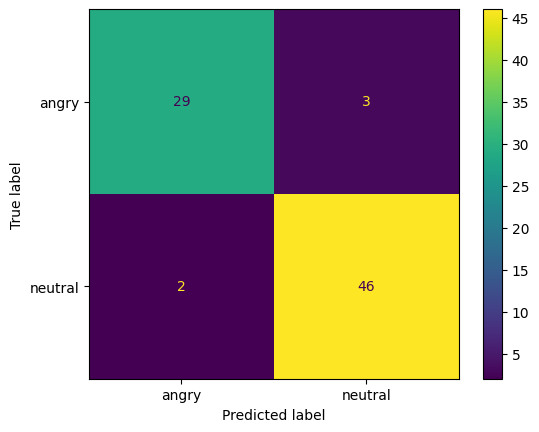

In [ ]:
best_params_svm = study.best_params
print("Najlepsze parametry:", best_params_svm)

best_model_svm = SVC(**best_params_svm)
best_preds_svm = best_model_svm.fit(X_train, y_train).predict(X_test)

print('F1', f1_score(y_test, best_preds_svm, average='weighted'))
print('Accuracy:', accuracy_score(y_test, best_preds_svm))

CMD.from_predictions(y_test, best_preds_svm)

Teraz przeprowadzimy te same kroki dla lasu losowego.

In [ ]:
RF = RandomForestClassifier(n_estimators=100, #random forest na domyslnych parametrach (przed optymalizacja)
    max_depth=None,
    random_state=42,
    class_weight='balanced')
RF.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

test accuracy = 0.8625
test F1 = 0.8637044115304985


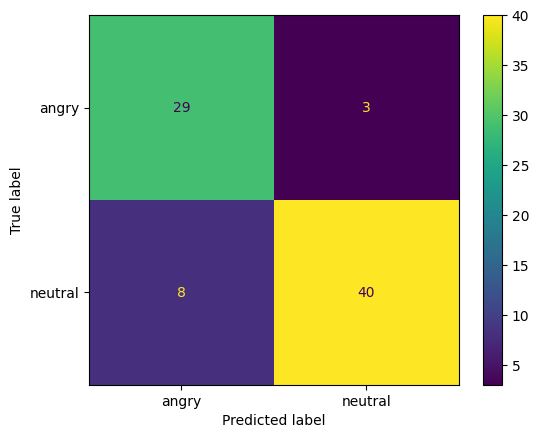

In [ ]:
RF_test_preds = RF.predict(X_test)

print("test accuracy =", accuracy_score(y_test, RF_test_preds))
print("test F1 =", f1_score(y_test, RF_test_preds, average='weighted'))
CMD.from_predictions(y_test, RF_test_preds)

Optymalizacja Random Forest

In [ ]:
scoring = {'f1_macro': 'f1_weighted'}
def get_space_rf(trial):
    space = {"n_estimators": trial.suggest_int("n_estimators", 200, 600),
             "max_depth": trial.suggest_int("max_depth", 5, 25),
             "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
             "n_jobs": trial.suggest_int("n_jobs", -1, -1)}
    return space

def objective(trial, model, get_space_rf, X, y, test_scoring):
    model_space = get_space_rf(trial)

    mdl = model(**model_space)
    scores = cross_validate(mdl, X, y,
                            scoring=scoring,
                            cv=StratifiedKFold(n_splits=5),
                            return_train_score=True)

    return np.mean(scores[test_scoring])

model_rf = RandomForestClassifier
trials_rf = 5 #ogolnie zwiekszyc do przynajmniej 10, ale dla oszczedzenia czas zmniejszylem do 5
sampler = TPESampler(seed=42)
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(lambda x: objective(x, model_rf, get_space_rf, X_train, y_train, 'test_f1_macro'), n_trials=trials_rf)

study_rf.best_params

print("Najwyższe wyniki z kroswalidacji:", study_rf.best_value)

[I 2025-12-15 09:06:47,096] A new study created in memory with name: no-name-882a62fa-2db1-47e2-b5cc-885e5678d7ec
[I 2025-12-15 09:06:59,643] Trial 0 finished with value: 0.9548976815059959 and parameters: {'n_estimators': 458, 'max_depth': 17, 'min_samples_split': 20, 'n_jobs': -1}. Best is trial 0 with value: 0.9548976815059959.
[I 2025-12-15 09:07:11,200] Trial 1 finished with value: 0.9548976815059959 and parameters: {'n_estimators': 422, 'max_depth': 12, 'min_samples_split': 13, 'n_jobs': -1}. Best is trial 0 with value: 0.9548976815059959.
[I 2025-12-15 09:07:25,341] Trial 2 finished with value: 0.9548976815059959 and parameters: {'n_estimators': 530, 'max_depth': 11, 'min_samples_split': 10, 'n_jobs': -1}. Best is trial 0 with value: 0.9548976815059959.
[I 2025-12-15 09:07:33,166] Trial 3 finished with value: 0.9499428136787877 and parameters: {'n_estimators': 272, 'max_depth': 18, 'min_samples_split': 15, 'n_jobs': -1}. Best is trial 0 with value: 0.9548976815059959.
[I 2025-12

Najwyższe wyniki z kroswalidacji: 0.9548976815059959


Tworzenie modelu na najlepszych parametrach dla random forest.

Najlepsze parametry: {'n_estimators': 458, 'max_depth': 17, 'min_samples_split': 20, 'n_jobs': -1}
F1 0.8514285714285714
Accuracy: 0.85


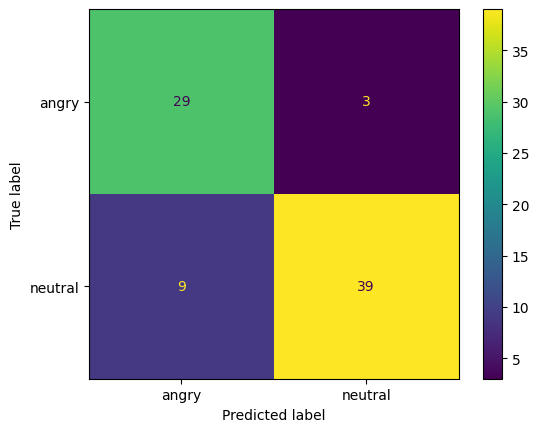

In [ ]:
best_params_rf = study_rf.best_params
print("Najlepsze parametry:", best_params_rf)

best_model_rf = RandomForestClassifier(**best_params_rf)
best_preds_rf = best_model_rf.fit(X_train, y_train).predict(X_test)

print('F1', f1_score(y_test, best_preds_rf, average='weighted'))
print('Accuracy:', accuracy_score(y_test, best_preds_rf))

CMD.from_predictions(y_test, best_preds_rf)

# Ostateczne zestawienie wyników

===== SVM – wyniki na zbiorze testowym =====
Accuracy            : 0.9375
F1-score (weighted) : 0.9373
Precision (weighted): 0.9375
Recall (weighted)   : 0.9375
              precision    recall  f1-score   support

       angry       0.94      0.91      0.92        32
     neutral       0.94      0.96      0.95        48

    accuracy                           0.94        80
   macro avg       0.94      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80


--------------------------------------------------------------

===== Random Forest – wyniki na zbiorze testowym =====
Accuracy            : 0.8500
F1-score (weighted) : 0.8514
Precision (weighted): 0.8624
Recall (weighted)   : 0.8500
              precision    recall  f1-score   support

       angry       0.76      0.91      0.83        32
     neutral       0.93      0.81      0.87        48

    accuracy                           0.85        80
   macro avg       0.85      0.86      0.85        80
weig

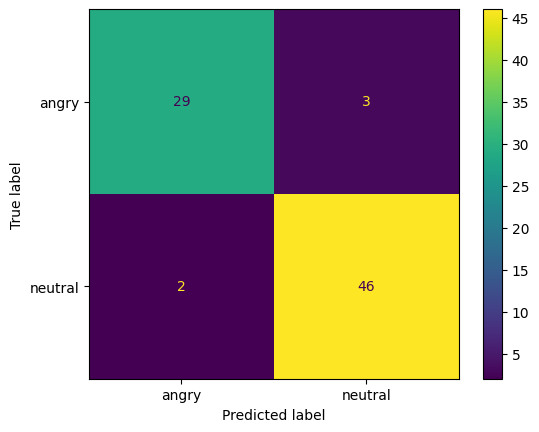

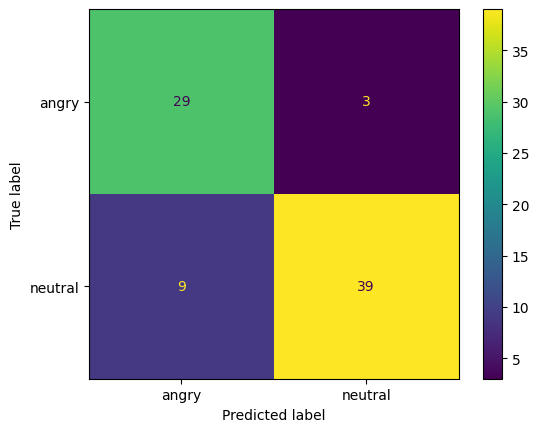

In [ ]:
print("===== SVM – wyniki na zbiorze testowym =====")
print(f"Accuracy            : {accuracy_score(y_test, best_preds_svm):.4f}")
print(f"F1-score (weighted) : {f1_score(y_test, best_preds_svm, average='weighted'):.4f}")
print(f"Precision (weighted): {precision_score(y_test, best_preds_svm, average='weighted'):.4f}")
print(f"Recall (weighted)   : {recall_score(y_test, best_preds_svm, average='weighted'):.4f}")
print(classification_report(y_test, best_preds_svm))
CMD.from_predictions(y_test, best_preds_svm)

print("\n--------------------------------------------------------------")

print("\n===== Random Forest – wyniki na zbiorze testowym =====")
print(f"Accuracy            : {accuracy_score(y_test, best_preds_rf):.4f}")
print(f"F1-score (weighted) : {f1_score(y_test, best_preds_rf, average='weighted'):.4f}")
print(f"Precision (weighted): {precision_score(y_test, best_preds_rf, average='weighted'):.4f}")
print(f"Recall (weighted)   : {recall_score(y_test, best_preds_rf, average='weighted'):.4f}")


print(classification_report(y_test, best_preds_rf))
CMD.from_predictions(y_test, best_preds_rf)

# Podsumowanie oraz analiza
Oba modele dla klasyfikacji wieloklasowej mają umiarkowaną skuteczność z wynikiem (accuracy oraz f1) zbliżonym do 40% na zbiorze testowym (losowe zgadywanie dawałoby ok. 14% accuracy).

Zarówno model SVM, jak i Random Forest najlepiej radzą sobie z rozpoznawaniem neutralnego zabarwienia wypowiedzi. W przypadku klasyfikacji wieloklasowej Random Forest osiąga wyraźnie lepsze wyniki, natomiast SVM sprawdza się lepiej w zadaniu binarnym (RF w tym przypadku może być bardziej podatny na lekkie nierówności w liczebności reprezentajci klas w zbiorze testowym).

Oba modele najczęściej błędnie klasyfikują emocję strachu, generalnie często ją nadając (wysoki recall, niskie precision), myląc ją tym samym z emocjami takimi jak szczęście, smutek oraz zaskoczenie.Dodatkowo klasy „sad” i „happy” są często pomijane, model ma trudności w wykrywaniu tych emocji, co objawia się niskim recall. Wynika to z faktu, że zbiór RAVDESS stanowi trudne zadanie klasyfikacyjne, szczególnie przy uwzględnieniu wszystkich dostępnych klas emocji. Również dla człowieka jednoznaczne określenie stanu emocjonalnego mówcy bywa niejednokrotnie problematyczne.

Zauważalna poprawa wyników pojawia się po ograniczeniu problemu do klasyfikacji binarnej. W takiej konfiguracji oba modele, zarówno w walidacji krzyżowej, jak i na zbiorze testowym, osiągają skuteczność rzędu 90% (zarówno pod względem Accuracy, jak i F1-score).

W celu dalszej poprawy jakości modeli oraz ograniczenia ryzyka przeuczenia (overfittingu), możliwe jest zastosowanie augmentacji danych (np. pitch shifting, time-stretching) lub połączenie zbioru RAVDESS z innym zbiorem danych o podobnej tematyce. Dodatkowo można rozważyć rozszerzenie zestawu obliczanych cech statystycznych o takie miary jak skośność czy kurtoza, co mogłoby dostarczyć modelom dodatkowych informacji o charakterystyce sygnału.